Running in Google Colab. Installing required packages...
Found existing CSV file: routerbench.csv
Using CSV_PATH = routerbench.csv
Using solver: appsi_highs
Loading RouterBench data...

Dataset summary
------------------------------------------------------------
Rows: 7,860
Unique prompts: 240
Unique models: 33
Prompts by dataset:
dataset
AIME        60
GPQA        60
LCB         60
MMLU-Pro    60
Name: count, dtype: int64

Prompt weights
------------------------------------------------------------
Total weight: 1.000000

Evaluating baselines...

Baseline results
                     policy  avg_cost  avg_score  models_used details
0  Single Best Global Model  0.042548   0.887500            1   gpt-5
1       Cheapest per Prompt  0.000000   0.566667            1        
2     Best Score per Prompt  0.001681   0.983333           24        

Solving recommended production router...
Status: ok
Termination: optimal

Recommended solution
------------------------------------------------------

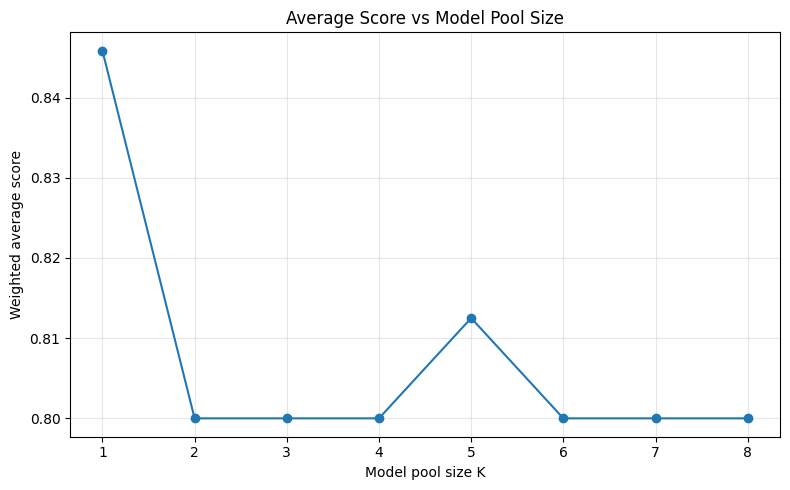

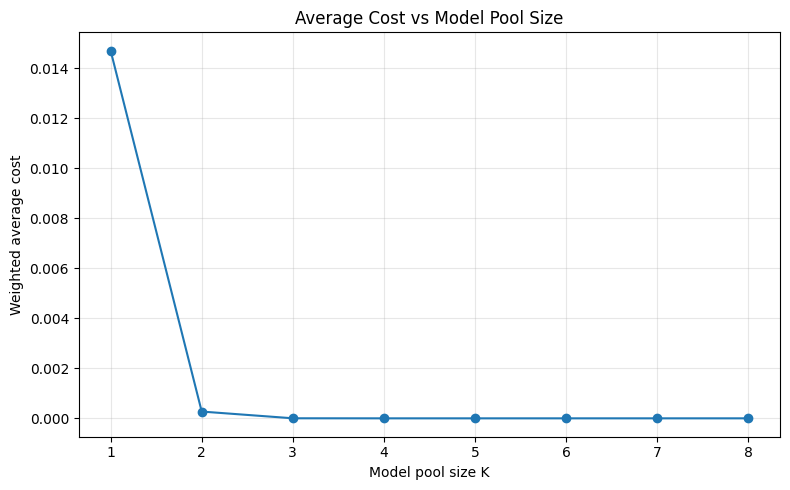

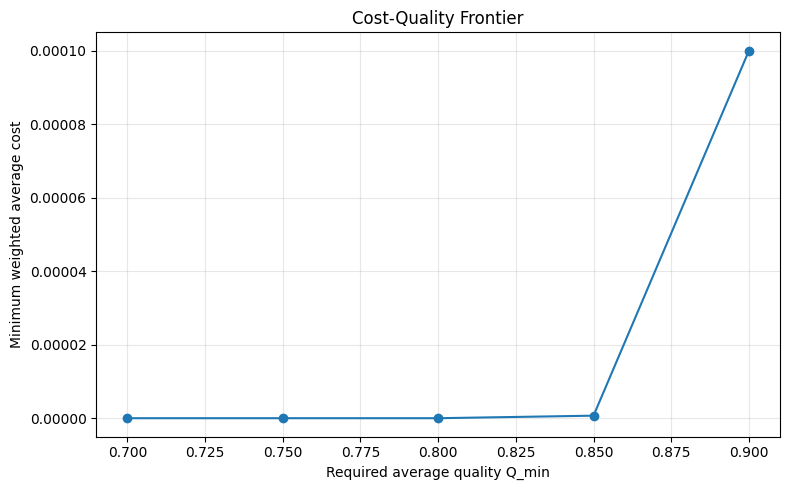

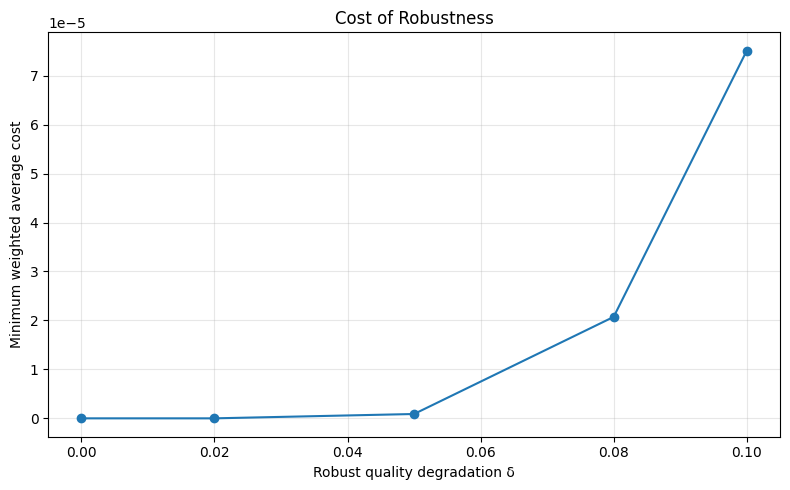

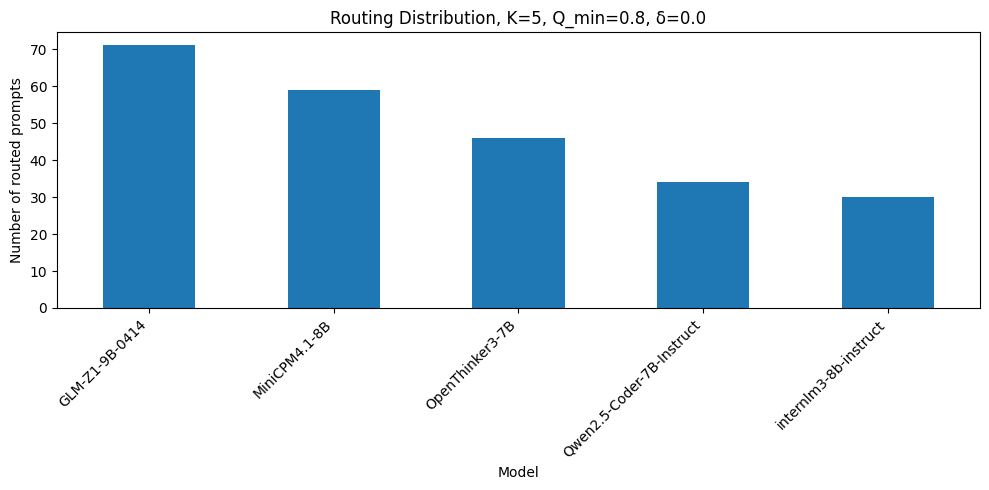

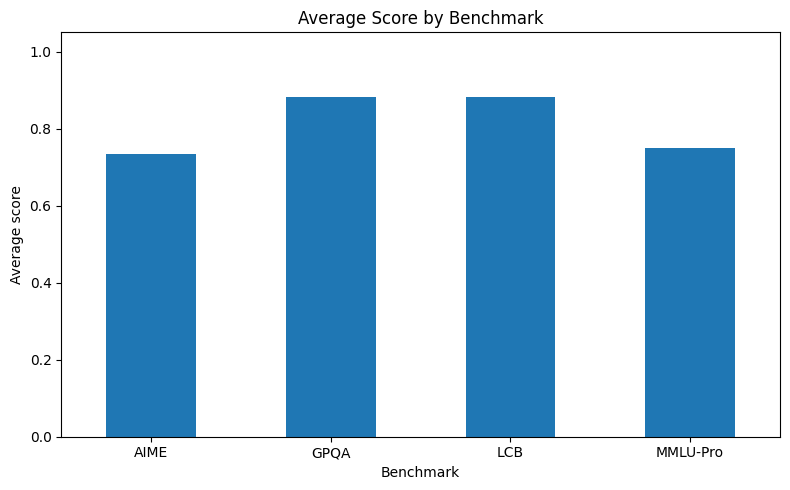


Saved all outputs to:
/content/project_outputs


In [3]:
from pathlib import Path
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo



if "google.colab" in sys.modules:
    print("Running in Google Colab. Installing required packages...")
    %pip install -q pyomo highspy

def get_csv_path(default_name="routerbench.csv"):

    if Path(default_name).exists():
        print(f"Found existing CSV file: {default_name}")
        return default_name

    try:
        import google.colab
        from google.colab import files

        print("Please upload routerbench.csv")
        uploaded = files.upload()

        if not uploaded:
            raise FileNotFoundError("No file was uploaded.")

        uploaded_filename = list(uploaded.keys())[0]
        print(f"Uploaded file: {uploaded_filename}")

        return uploaded_filename

    except ImportError:
        csv_path = input("Enter path to routerbench.csv: ").strip()

        if not Path(csv_path).exists():
            raise FileNotFoundError(f"File not found: {csv_path}")

        return csv_path


CSV_PATH = get_csv_path()
print(f"Using CSV_PATH = {CSV_PATH}")

OUTPUT_DIR = Path("project_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

SOLVER_NAME = "appsi_highs"

K_GRID = [1, 2, 3, 4, 5, 6, 7, 8]
Q_GRID = [0.70, 0.75, 0.80, 0.85, 0.90]
DELTA_GRID = [0.00, 0.02, 0.05, 0.08, 0.10]

DEFAULT_K = 5
DEFAULT_Q_MIN = 0.80
DEFAULT_DELTA = 0.00
DEFAULT_BENCHMARK_Q_MIN = 0.70

#be sure to minimize cost first; if two routes have the same cost, prefer the higher-score one.
EPS_SCORE_TIEBREAKER = 1e-6


def choose_solver():
    solver = pyo.SolverFactory(SOLVER_NAME)

    if solver is not None and solver.available(False):
        print(f"Using solver: {SOLVER_NAME}")
        return solver

    fallback = pyo.SolverFactory("glpk")

    if fallback is not None and fallback.available(False):
        print("Using solver: glpk")
        return fallback

    raise RuntimeError(
        "No solver found. In Colab, run: !pip install pyomo highspy"
    )


SOLVER = choose_solver()


#data loading layer and keeps only the columns needed for the model

def load_routerbench_data(csv_path):
    """
    Loads routerbench.csv

    Expected columns:dataset, prompt_id, model, score, cost
    """
    df = pd.read_csv(csv_path)

    required_cols = ["dataset", "prompt_id", "model", "score", "cost"]
    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise ValueError(f"CSV is missing required columns: {missing}")

    df = df[required_cols].copy()

    df["dataset"] = df["dataset"].astype(str)
    df["prompt_id"] = df["prompt_id"].astype(str)
    df["model"] = df["model"].astype(str)

    #converts score and cost to numeric values in case the CSV has strings or blanks

    df["score"] = pd.to_numeric(df["score"], errors="coerce").fillna(0.0)
    df["cost"] = pd.to_numeric(df["cost"], errors="coerce").fillna(0.0)

    dupes = df.duplicated(subset=["prompt_id", "model"])

    if dupes.any():
        print(f"Warning: found {dupes.sum()} duplicate prompt-model rows. Keeping first.")
        df = df.drop_duplicates(subset=["prompt_id", "model"], keep="first")

    return df

#prompt weights function, empirical distribution
def build_prompt_weights(df, scheme="equal"):
    """
    Builds SAA weights for prompts.

    scheme = "equal":
        every prompt receives equal probability.

    scheme = "equal_by_dataset":
        every dataset receives equal mass,
        then each prompt inside that dataset receives equal mass.
    """
    prompt_dataset = (
        df[["prompt_id", "dataset"]]
        .drop_duplicates()
        .set_index("prompt_id")["dataset"]
        .to_dict()
    )

    prompts = sorted(prompt_dataset.keys())
    datasets = sorted(set(prompt_dataset.values()))

    if scheme == "equal":
        return {p: 1.0 / len(prompts) for p in prompts}

    if scheme == "equal_by_dataset":
        weights = {}

        for d in datasets:
            prompts_d = [p for p in prompts if prompt_dataset[p] == d]

            for p in prompts_d:
                weights[p] = 1.0 / len(datasets) / len(prompts_d)

        return weights

    raise ValueError("Unknown weighting scheme.")

#simulating future usage mixes for prompts
def build_prompt_weights_custom(df, dataset_weights):
    """
    Builds custom prompt weights for prompt-distribution sensitivity.
    """
    prompt_dataset = (
        df[["prompt_id", "dataset"]]
        .drop_duplicates()
        .set_index("prompt_id")["dataset"]
        .to_dict()
    )

    weights = {}
    #spreads each dataset's assigned probability mass evenly across prompts
    for d, mass in dataset_weights.items():
        prompts_d = [p for p, dd in prompt_dataset.items() if dd == d]

        if len(prompts_d) == 0:
            continue

        for p in prompts_d:
            weights[p] = mass / len(prompts_d)

    total_assigned = sum(weights.values())
    missing_prompts = [p for p in prompt_dataset if p not in weights]

    if missing_prompts:
        remaining_mass = max(0.0, 1.0 - total_assigned)

        for p in missing_prompts:
            weights[p] = remaining_mass / len(missing_prompts)
    #normalize
    total = sum(weights.values())
    weights = {p: w / total for p, w in weights.items()}

    return weights


def make_parameter_dicts(df):
    """
    Creates sets and dictionaries for Pyomo.
    """
    prompts = sorted(df["prompt_id"].unique().tolist())
    models = sorted(df["model"].unique().tolist())
    datasets = sorted(df["dataset"].unique().tolist())

    score = {}
    cost = {}
    dataset_of_prompt = {}

    for _, row in df.iterrows():
        p = row["prompt_id"]
        m = row["model"]
        d = row["dataset"]

        score[(p, m)] = float(row["score"])
        cost[(p, m)] = float(row["cost"])
        dataset_of_prompt[p] = d

    available_pairs = sorted(score.keys())

    prompts_by_dataset = {
        d: sorted(df[df["dataset"] == d]["prompt_id"].unique().tolist())
        for d in datasets
    }

    return (
        prompts,
        models,
        datasets,
        available_pairs,
        score,
        cost,
        dataset_of_prompt,
        prompts_by_dataset,
    )


#routing model
#chooses a small model pool, then routes each prompt
#to one selected model while meeting the quality requirement

def solve_pool_router(
    df,
    K,
    Q_min,
    prompt_weights,
    benchmark_q_min=None,
    robust_delta=0.0,
    require_at_least_one_paid=False,
    require_at_least_one_free=False,
    verbose=False,
):
    """
    Two-stage Cursor LLM routing model.
    Constraints:
        1. Each prompt is assigned to exactly one model.
        2. Prompts can only be routed to selected models.
        3. At most K models are selected.
        4. Weighted average robust score >= Q_min.
        5. Optional benchmark fairness constraints.
        6. Optional paid/free diversity constraints.
    """

    (
        prompts,
        models,
        datasets,
        available_pairs,
        score,
        cost,
        dataset_of_prompt,
        prompts_by_dataset,
    ) = make_parameter_dicts(df)

    if benchmark_q_min is None:
        benchmark_q_min = {}

    #builds the optimization model
    mdl = pyo.ConcreteModel()

    mdl.P = pyo.Set(initialize=prompts)
    mdl.M = pyo.Set(initialize=models)
    mdl.PM = pyo.Set(initialize=available_pairs, dimen=2)

    mdl.w = pyo.Param(mdl.P, initialize=prompt_weights, within=pyo.NonNegativeReals)
    mdl.score = pyo.Param(mdl.PM, initialize=score, within=pyo.Reals)
    mdl.cost = pyo.Param(mdl.PM, initialize=cost, within=pyo.NonNegativeReals)

    #these are all of the decision variables
    mdl.x = pyo.Var(mdl.PM, within=pyo.Binary)
    mdl.z = pyo.Var(mdl.M, within=pyo.Binary)

    #objective function which is to minimize weighted average routing cost.
    #the small score tie-breaker selects the highest-score solution among cost-equivalent routers.
    def objective_rule(mdl):
        avg_cost_expr = sum(
            mdl.w[p] * mdl.cost[p, m] * mdl.x[p, m]
            for (p, m) in mdl.PM
        )

        avg_score_expr = sum(
            mdl.w[p] * mdl.score[p, m] * mdl.x[p, m]
            for (p, m) in mdl.PM
        )

        return avg_cost_expr - EPS_SCORE_TIEBREAKER * avg_score_expr

    mdl.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    #each prompt gets exactly one model
    def assignment_rule(mdl, p):
        feasible_models = [m for (pp, m) in mdl.PM if pp == p]
        return sum(mdl.x[p, m] for m in feasible_models) == 1

    mdl.assignment = pyo.Constraint(mdl.P, rule=assignment_rule)

    #can only route to selected models
    def linking_rule(mdl, p, m):
        return mdl.x[p, m] <= mdl.z[m]

    mdl.linking = pyo.Constraint(mdl.PM, rule=linking_rule)

    #selected model pool size
    mdl.pool_size = pyo.Constraint(
        expr=sum(mdl.z[m] for m in models) <= K
    )

    #pessimistic quality score
    robust_score = {
        (p, m): max(score[(p, m)] - robust_delta, 0.0)
        for (p, m) in available_pairs
    }

    #average robust quality requirement
    mdl.avg_quality = pyo.Constraint(
        expr=sum(
            prompt_weights[p] * robust_score[(p, m)] * mdl.x[p, m]
            for (p, m) in available_pairs
        ) >= Q_min
    )

    #benchmark fairness constraints
    mdl.benchmark_fairness = pyo.ConstraintList()

    for d, threshold in benchmark_q_min.items():
        prompts_d = prompts_by_dataset.get(d, [])

        if not prompts_d:
            continue

        total_weight_d = sum(prompt_weights[p] for p in prompts_d)

        if total_weight_d <= 0:
            continue

        pairs_d = [(p, m) for (p, m) in available_pairs if p in prompts_d]

        mdl.benchmark_fairness.add(
            sum(
                prompt_weights[p] * robust_score[(p, m)] * mdl.x[p, m]
                for (p, m) in pairs_d
            ) / total_weight_d >= threshold
        )

    #optional realistic constraints: require at least one free/paid model
    avg_model_cost = {
        m: np.mean([cost[(p, m)] for p in prompts if (p, m) in cost])
        for m in models
    }

    free_models = [m for m in models if avg_model_cost[m] == 0]
    paid_models = [m for m in models if avg_model_cost[m] > 0]

    if require_at_least_one_free and free_models:
        mdl.at_least_one_free = pyo.Constraint(
            expr=sum(mdl.z[m] for m in free_models) >= 1
        )

    if require_at_least_one_paid and paid_models:
        mdl.at_least_one_paid = pyo.Constraint(
            expr=sum(mdl.z[m] for m in paid_models) >= 1
        )

    #solver
    results = SOLVER.solve(mdl, tee=False)

    termination = results.solver.termination_condition
    status = results.solver.status

    if verbose:
        print("Status:", status)
        print("Termination:", termination)

    if termination not in [
        pyo.TerminationCondition.optimal,
        pyo.TerminationCondition.feasible,
    ]:
        return {
            "status": str(status),
            "termination": str(termination),
            "K": K,
            "Q_min": Q_min,
            "robust_delta": robust_delta,
            "avg_cost": np.nan,
            "avg_score": np.nan,
            "robust_avg_score": np.nan,
            "selected_models": [],
            "assignments": pd.DataFrame(),
            "benchmark_scores": {},
            "benchmark_costs": {},
            "model_usage": {},
        }

    selected_models = [
        m for m in models
        if pyo.value(mdl.z[m]) is not None and pyo.value(mdl.z[m]) > 0.5
    ]

    assignment_rows = []

    for (p, m) in available_pairs:
        val = pyo.value(mdl.x[p, m])

        if val is not None and val > 0.5:
            assignment_rows.append({
                "prompt_id": p,
                "dataset": dataset_of_prompt[p],
                "model": m,
                "weight": prompt_weights[p],
                "score": score[(p, m)],
                "robust_score": robust_score[(p, m)],
                "cost": cost[(p, m)],
            })

    assignments = pd.DataFrame(assignment_rows)

    avg_cost = float((assignments["weight"] * assignments["cost"]).sum())
    avg_score = float((assignments["weight"] * assignments["score"]).sum())
    robust_avg_score = float((assignments["weight"] * assignments["robust_score"]).sum())

    benchmark_scores = {}
    benchmark_costs = {}

    for d in datasets:
        sub = assignments[assignments["dataset"] == d].copy()

        if len(sub) == 0:
            benchmark_scores[d] = np.nan
            benchmark_costs[d] = np.nan
        else:
            total_w = sub["weight"].sum()
            benchmark_scores[d] = float((sub["weight"] * sub["score"]).sum() / total_w)
            benchmark_costs[d] = float((sub["weight"] * sub["cost"]).sum() / total_w)

    model_usage = assignments["model"].value_counts().to_dict()

    return {
        "status": str(status),
        "termination": str(termination),
        "K": K,
        "Q_min": Q_min,
        "robust_delta": robust_delta,
        "avg_cost": avg_cost,
        "avg_score": avg_score,
        "robust_avg_score": robust_avg_score,
        "selected_models": selected_models,
        "assignments": assignments.sort_values(["dataset", "prompt_id"]).reset_index(drop=True),
        "benchmark_scores": benchmark_scores,
        "benchmark_costs": benchmark_costs,
        "model_usage": model_usage,
    }


def evaluate_single_best(df, prompt_weights):
    """
    Baseline:
    Pick one global model for all prompts.
    Choose highest average score, tie-break by lower cost.
    """
    (
        prompts,
        models,
        datasets,
        available_pairs,
        score,
        cost,
        dataset_of_prompt,
        prompts_by_dataset,
    ) = make_parameter_dicts(df)

    rows = []

    for m in models:
        pairs_m = [(p, mm) for (p, mm) in available_pairs if mm == m]
        covered = set(p for (p, _) in pairs_m)

        if covered != set(prompts):
            continue

        avg_score = sum(prompt_weights[p] * score[(p, m)] for p in prompts)
        avg_cost = sum(prompt_weights[p] * cost[(p, m)] for p in prompts)

        rows.append({
            "model": m,
            "avg_score": avg_score,
            "avg_cost": avg_cost,
        })

    out = pd.DataFrame(rows)
    out = out.sort_values(["avg_score", "avg_cost"], ascending=[False, True]).reset_index(drop=True)

    return out.iloc[0].to_dict()


def evaluate_cheapest_per_prompt(df, prompt_weights):
    """
    Baseline:
    Route every prompt to its cheapest available model.
    """
    (
        prompts,
        models,
        datasets,
        available_pairs,
        score,
        cost,
        dataset_of_prompt,
        prompts_by_dataset,
    ) = make_parameter_dicts(df)

    rows = []

    for p in prompts:
        feasible = [m for (pp, m) in available_pairs if pp == p]
        best_m = min(feasible, key=lambda m: cost[(p, m)])

        rows.append({
            "prompt_id": p,
            "dataset": dataset_of_prompt[p],
            "model": best_m,
            "weight": prompt_weights[p],
            "score": score[(p, best_m)],
            "cost": cost[(p, best_m)],
        })

    assignments = pd.DataFrame(rows)

    return {
        "policy": "Cheapest per Prompt",
        "avg_cost": float((assignments["weight"] * assignments["cost"]).sum()),
        "avg_score": float((assignments["weight"] * assignments["score"]).sum()),
        "models_used": assignments["model"].nunique(),
        "assignments": assignments,
    }


def evaluate_best_score_per_prompt(df, prompt_weights):
    """
    Baseline:
    Route every prompt to the highest-score model.
    Tie-break by lower cost.
    """
    (
        prompts,
        models,
        datasets,
        available_pairs,
        score,
        cost,
        dataset_of_prompt,
        prompts_by_dataset,
    ) = make_parameter_dicts(df)

    rows = []

    for p in prompts:
        feasible = [m for (pp, m) in available_pairs if pp == p]

        best_m = sorted(
            feasible,
            key=lambda m: (-score[(p, m)], cost[(p, m)])
        )[0]

        rows.append({
            "prompt_id": p,
            "dataset": dataset_of_prompt[p],
            "model": best_m,
            "weight": prompt_weights[p],
            "score": score[(p, best_m)],
            "cost": cost[(p, best_m)],
        })

    assignments = pd.DataFrame(rows)

    return {
        "policy": "Best Score per Prompt",
        "avg_cost": float((assignments["weight"] * assignments["cost"]).sum()),
        "avg_score": float((assignments["weight"] * assignments["score"]).sum()),
        "models_used": assignments["model"].nunique(),
        "assignments": assignments,
    }

#experiments

def run_pool_size_experiment(df, prompt_weights):

    #how large should Cursor's model pool be?

    datasets = sorted(df["dataset"].unique().tolist())

    benchmark_thresholds = {
        d: DEFAULT_BENCHMARK_Q_MIN
        for d in datasets
    }

    records = []

    for K in K_GRID:
        print(f"Solving pool-size experiment: K={K}")

        result = solve_pool_router(
            df=df,
            K=K,
            Q_min=DEFAULT_Q_MIN,
            prompt_weights=prompt_weights,
            benchmark_q_min=benchmark_thresholds,
            robust_delta=DEFAULT_DELTA,
            verbose=False,
        )

        row = {
            "K": K,
            "termination": result["termination"],
            "avg_cost": result["avg_cost"],
            "avg_score": result["avg_score"],
            "robust_avg_score": result["robust_avg_score"],
            "num_selected": len(result["selected_models"]),
            "selected_models": "; ".join(result["selected_models"]),
        }

        for d, val in result["benchmark_scores"].items():
            row[f"score_{d}"] = val

        records.append(row)

    out = pd.DataFrame(records)
    out.to_csv(OUTPUT_DIR / "experiment_1_pool_size.csv", index=False)

    return out


def run_quality_frontier_experiment(df, prompt_weights):
    """
    Experiment 2:
    Vary Q_min.

    Research question:
    How much cost is required to guarantee higher quality?
    """
    records = []

    for q in Q_GRID:
        print(f"Solving quality-frontier experiment: Q_min={q}")

        result = solve_pool_router(
            df=df,
            K=DEFAULT_K,
            Q_min=q,
            prompt_weights=prompt_weights,
            benchmark_q_min=None,
            robust_delta=DEFAULT_DELTA,
            verbose=False,
        )

        row = {
            "Q_min": q,
            "termination": result["termination"],
            "avg_cost": result["avg_cost"],
            "avg_score": result["avg_score"],
            "robust_avg_score": result["robust_avg_score"],
            "num_selected": len(result["selected_models"]),
            "selected_models": "; ".join(result["selected_models"]),
        }

        records.append(row)

    out = pd.DataFrame(records)
    out.to_csv(OUTPUT_DIR / "experiment_2_quality_frontier.csv", index=False)

    return out


def run_robustness_experiment(df, prompt_weights):
    """
    Experiment 3:
    Vary robust_delta.

    Research question:
    What is the cost of robustness?
    """
    records = []

    for delta in DELTA_GRID:
        print(f"Solving robustness experiment: delta={delta}")

        result = solve_pool_router(
            df=df,
            K=DEFAULT_K,
            Q_min=DEFAULT_Q_MIN,
            prompt_weights=prompt_weights,
            benchmark_q_min=None,
            robust_delta=delta,
            verbose=False,
        )

        row = {
            "delta": delta,
            "termination": result["termination"],
            "avg_cost": result["avg_cost"],
            "avg_score_nominal": result["avg_score"],
            "avg_score_robust": result["robust_avg_score"],
            "num_selected": len(result["selected_models"]),
            "selected_models": "; ".join(result["selected_models"]),
        }

        records.append(row)

    out = pd.DataFrame(records)
    out.to_csv(OUTPUT_DIR / "experiment_3_robustness.csv", index=False)

    return out


def run_prompt_distribution_experiment(df):
    """
    Experiment 4:
    Change prompt distribution weights to simulate different products.
    """
    scenarios = {
        "balanced": None,
        "coding_heavy": {
            "LCB": 0.55,
            "AIME": 0.15,
            "GPQA": 0.15,
            "MMLU-Pro": 0.15,
        },
        "math_heavy": {
            "AIME": 0.55,
            "LCB": 0.15,
            "GPQA": 0.15,
            "MMLU-Pro": 0.15,
        },
        "knowledge_heavy": {
            "GPQA": 0.35,
            "MMLU-Pro": 0.35,
            "AIME": 0.15,
            "LCB": 0.15,
        },
    }

    records = []

    for scenario, weights_dict in scenarios.items():
        print(f"Solving prompt-distribution experiment: {scenario}")

        if weights_dict is None:
            prompt_weights = build_prompt_weights(df, scheme="equal")
        else:
            prompt_weights = build_prompt_weights_custom(df, weights_dict)

        result = solve_pool_router(
            df=df,
            K=DEFAULT_K,
            Q_min=DEFAULT_Q_MIN,
            prompt_weights=prompt_weights,
            benchmark_q_min=None,
            robust_delta=DEFAULT_DELTA,
            verbose=False,
        )

        row = {
            "scenario": scenario,
            "termination": result["termination"],
            "avg_cost": result["avg_cost"],
            "avg_score": result["avg_score"],
            "robust_avg_score": result["robust_avg_score"],
            "num_selected": len(result["selected_models"]),
            "selected_models": "; ".join(result["selected_models"]),
        }

        for d, val in result["benchmark_scores"].items():
            row[f"score_{d}"] = val

        records.append(row)

    out = pd.DataFrame(records)
    out.to_csv(OUTPUT_DIR / "experiment_4_prompt_distribution.csv", index=False)

    return out


#plotting

def plot_pool_size_results(pool_df):
    feasible = pool_df.dropna(subset=["avg_cost", "avg_score"])

    plt.figure(figsize=(8, 5))
    plt.plot(feasible["K"], feasible["avg_score"], marker="o")
    plt.xlabel("Model pool size K")
    plt.ylabel("Weighted average score")
    plt.title("Average Score vs Model Pool Size")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "plot_pool_size_vs_score.png", dpi=250)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(feasible["K"], feasible["avg_cost"], marker="o")
    plt.xlabel("Model pool size K")
    plt.ylabel("Weighted average cost")
    plt.title("Average Cost vs Model Pool Size")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "plot_pool_size_vs_cost.png", dpi=250)
    plt.show()


def plot_quality_frontier(frontier_df):
    feasible = frontier_df.dropna(subset=["avg_cost", "avg_score"])

    plt.figure(figsize=(8, 5))
    plt.plot(feasible["Q_min"], feasible["avg_cost"], marker="o")
    plt.xlabel("Required average quality Q_min")
    plt.ylabel("Minimum weighted average cost")
    plt.title("Cost-Quality Frontier")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "plot_cost_quality_frontier.png", dpi=250)
    plt.show()


def plot_robustness_results(robust_df):
    feasible = robust_df.dropna(subset=["avg_cost"])

    plt.figure(figsize=(8, 5))
    plt.plot(feasible["delta"], feasible["avg_cost"], marker="o")
    plt.xlabel("Robust quality degradation δ")
    plt.ylabel("Minimum weighted average cost")
    plt.title("Cost of Robustness")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "plot_cost_of_robustness.png", dpi=250)
    plt.show()


def plot_model_usage(result, filename="plot_model_usage.png"):
    usage = pd.Series(result["model_usage"]).sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    usage.plot(kind="bar")
    plt.xlabel("Model")
    plt.ylabel("Number of routed prompts")
    plt.title(
        f"Routing Distribution, K={result['K']}, "
        f"Q_min={result['Q_min']}, δ={result['robust_delta']}"
    )
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=250)
    plt.show()


def plot_benchmark_scores(result, filename="plot_benchmark_scores.png"):
    scores = pd.Series(result["benchmark_scores"]).sort_index()

    plt.figure(figsize=(8, 5))
    scores.plot(kind="bar")
    plt.xlabel("Benchmark")
    plt.ylabel("Average score")
    plt.title("Average Score by Benchmark")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=250)
    plt.show()


#runner

def main_project():
    print("Loading RouterBench data...")
    df = load_routerbench_data(CSV_PATH)

    print("\nDataset summary")
    print("-" * 60)
    print(f"Rows: {len(df):,}")
    print(f"Unique prompts: {df['prompt_id'].nunique():,}")
    print(f"Unique models: {df['model'].nunique():,}")
    print("Prompts by dataset:")
    print(df[["prompt_id", "dataset"]].drop_duplicates()["dataset"].value_counts().sort_index())

    prompt_weights = build_prompt_weights(df, scheme="equal")

    print("\nPrompt weights")
    print("-" * 60)
    print(f"Total weight: {sum(prompt_weights.values()):.6f}")

    print("\nEvaluating baselines...")
    single_best = evaluate_single_best(df, prompt_weights)
    cheapest = evaluate_cheapest_per_prompt(df, prompt_weights)
    best_score = evaluate_best_score_per_prompt(df, prompt_weights)

    baseline_df = pd.DataFrame([
        {
            "policy": "Single Best Global Model",
            "avg_cost": single_best["avg_cost"],
            "avg_score": single_best["avg_score"],
            "models_used": 1,
            "details": single_best["model"],
        },
        {
            "policy": cheapest["policy"],
            "avg_cost": cheapest["avg_cost"],
            "avg_score": cheapest["avg_score"],
            "models_used": cheapest["models_used"],
            "details": "",
        },
        {
            "policy": best_score["policy"],
            "avg_cost": best_score["avg_cost"],
            "avg_score": best_score["avg_score"],
            "models_used": best_score["models_used"],
            "details": "",
        },
    ])

    baseline_df.to_csv(OUTPUT_DIR / "baseline_results.csv", index=False)

    print("\nBaseline results")
    print(baseline_df)

    print("\nSolving recommended production router...")
    datasets = sorted(df["dataset"].unique().tolist())
    benchmark_thresholds = {d: DEFAULT_BENCHMARK_Q_MIN for d in datasets}

    recommended = solve_pool_router(
        df=df,
        K=DEFAULT_K,
        Q_min=DEFAULT_Q_MIN,
        prompt_weights=prompt_weights,
        benchmark_q_min=benchmark_thresholds,
        robust_delta=DEFAULT_DELTA,
        verbose=True,
    )

    recommended["assignments"].to_csv(
        OUTPUT_DIR / "recommended_assignments.csv",
        index=False
    )

    recommended_summary = {
        "K": recommended["K"],
        "Q_min": recommended["Q_min"],
        "robust_delta": recommended["robust_delta"],
        "termination": recommended["termination"],
        "avg_cost": recommended["avg_cost"],
        "avg_score": recommended["avg_score"],
        "robust_avg_score": recommended["robust_avg_score"],
        "selected_models": "; ".join(recommended["selected_models"]),
    }

    pd.DataFrame([recommended_summary]).to_csv(
        OUTPUT_DIR / "recommended_summary.csv",
        index=False
    )

    print("\nRecommended solution")
    print("-" * 60)
    print(f"Termination: {recommended['termination']}")
    print(f"K: {recommended['K']}")
    print(f"Q_min: {recommended['Q_min']}")
    print(f"Average cost: {recommended['avg_cost']:.8f}")
    print(f"Average score: {recommended['avg_score']:.4f}")
    print(f"Robust average score: {recommended['robust_avg_score']:.4f}")

    print("Selected models:")
    for m in recommended["selected_models"]:
        print(" -", m)

    print("\nBenchmark scores:")
    for d, s in recommended["benchmark_scores"].items():
        print(f"  {d}: {s:.4f}")

    print("\nModel usage:")
    for m, count in recommended["model_usage"].items():
        print(f"  {m}: {count}")

    print("\nRunning experiment 1: pool size...")
    pool_df = run_pool_size_experiment(df, prompt_weights)
    print(pool_df)

    print("\nRunning experiment 2: quality frontier...")
    frontier_df = run_quality_frontier_experiment(df, prompt_weights)
    print(frontier_df)

    print("\nRunning experiment 3: robustness...")
    robust_df = run_robustness_experiment(df, prompt_weights)
    print(robust_df)

    print("\nRunning experiment 4: prompt distribution sensitivity...")
    distribution_df = run_prompt_distribution_experiment(df)
    print(distribution_df)

    print("\nGenerating plots...")
    plot_pool_size_results(pool_df)
    plot_quality_frontier(frontier_df)
    plot_robustness_results(robust_df)
    plot_model_usage(recommended)
    plot_benchmark_scores(recommended)

    print("\nSaved all outputs to:")
    print(OUTPUT_DIR.resolve())

    return {
        "df": df,
        "baseline_df": baseline_df,
        "recommended": recommended,
        "pool_df": pool_df,
        "frontier_df": frontier_df,
        "robust_df": robust_df,
        "distribution_df": distribution_df,
    }


#running full project

project_results = main_project()